# 03 — Modelado de Churn (Random Forest, XGBoost, Decision Tree)

## Contexto

Este notebook entrena el modelo final del TP. Cumple con el protocolo de la skill `/ds-model`:
- **Baseline dummy obligatorio** para tener un piso de comparación válido
- **Mínimo 4 métricas** reportadas (acá usamos 5: F1, Recall, Precision, PR-AUC, AUC-ROC)
- **Criterio del ganador escrito ANTES de ver resultados** (sección 4)
- **Test set tocado una sola vez** al final (sección 10)
- **Seeds fijos en todo** (`RANDOM_STATE = 42`)
- **Tuning solo si la mejora supera 2%** en la métrica primaria

## Plan del modelado

Cuatro familias de modelos + dummy baseline:

| Modelo | Por qué |
|---|---|
| `DummyClassifier(strategy='most_frequent')` | Piso obligatorio — predice siempre "no churn" |
| `DecisionTreeClassifier` | Obligatorio per rúbrica — interpretable como reglas if/then |
| `RandomForestClassifier` | Captura interacciones nativamente (ver `02b`) |
| `XGBClassifier` | Esperado mejor performance en tabular desbalanceado |

Plus: tuning **bayesiano** de los top 2 (`BayesSearchCV`), análisis **SHAP** global + local, y **audit de leakage** sobre `Complain`.

## Dataset

Primary: `data/processed/train_sin_complain.csv` (4504 × 36) y `test_sin_complain.csv` (1126 × 36).

Por qué `sin_complain` como primary: el dataset es público y no podemos verificar si la queja se registra antes o después del churn. Postura conservadora — entrenamos sin la variable. Después un audit cuantitativo en `con_complain` mide el gap, para defender la decisión con evidencia (sección 14).

Toda la información que el modelado necesita está en `reports/handoff_to_modeler.md`.

In [1]:
# Librerías estándar
import warnings
import time
import json
from pathlib import Path

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluación + CV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    f1_score, recall_score, precision_score, average_precision_score,
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc,
)

# Tuning bayesiano
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Interpretabilidad
import shap

# Display
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
CHURN_COLORS = {0: '#2ecc71', 1: '#e74c3c'}
warnings.filterwarnings('ignore', category=UserWarning)

RANDOM_STATE = 42
REPORTS_DIR = Path('../reports')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('Setup completo.')
print(f'  xgboost: importado')
print(f'  scikit-optimize: importado (BayesSearchCV)')
print(f'  shap: importado')

Setup completo.
  xgboost: importado
  scikit-optimize: importado (BayesSearchCV)
  shap: importado


In [2]:
# Train + test SIN Complain (postura conservadora — ver sección 4 y audit en sección 14)
train = pd.read_csv('../data/processed/train_sin_complain.csv')
test  = pd.read_csv('../data/processed/test_sin_complain.csv')

print(f'Train: {train.shape[0]:,} filas × {train.shape[1]} columnas')
print(f'Test:  {test.shape[0]:,} filas × {test.shape[1]} columnas')
print(f'Churn rate train: {train["Churn"].mean()*100:.2f}%')
print(f'Churn rate test:  {test["Churn"].mean()*100:.2f}%')
print(f'Nulos en train:   {train.isna().sum().sum()}')
print(f'Nulos en test:    {test.isna().sum().sum()}')

y_train = train['Churn']
X_train = train.drop(columns=['Churn'])

# OJO: y_test y X_test los preparamos pero NO los usamos hasta la sección 10
y_test = test['Churn']
X_test = test.drop(columns=['Churn'])
print(f'\nFeatures disponibles: {X_train.shape[1]}')

Train: 4,504 filas × 36 columnas
Test:  1,126 filas × 36 columnas
Churn rate train: 16.83%
Churn rate test:  16.87%
Nulos en train:   0
Nulos en test:    0

Features disponibles: 35


---

## 4. Spec del experimento (escrito ANTES de ver resultados)

**Esta sección define el criterio de elección del ganador antes de entrenar nada.**
Es la regla más importante del protocolo `/ds-model`: sin criterio escrito ANTES, cualquier elección posterior es cherry-picking.

```
Métrica primaria (optimización CV): Recall (clase 1 = Churn)
Justificación: costo asimétrico — perder un churner cuesta mucho más que un falso positivo
              (la consigna lo establece explícitamente; ver decisions.md decisión #1).

Métricas de reporte (5, supera el mínimo de 4 del skill):
  • F1 (balance precision/recall)
  • Recall (primaria)
  • Precision (qué % de los predichos eran realmente churners)
  • PR-AUC (= average_precision; informativa con desbalance)
  • AUC-ROC (clásica, comparable con literatura)

Cross-validation: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Baseline obligatorio: DummyClassifier(strategy='most_frequent')

Threshold de aceptación del ganador:
  • Recall (CV mean) > Dummy + 0.05 (diferencia mínima razonable)
  • Gap train-test en Recall ≤ 0.05 (overfitting controlado)

Criterio de elección del ganador:
  • Máximo Recall en CV de 5 folds (primario)
  • Desempate por PR-AUC (secundario)

Tuning (Bayesian optimization con BayesSearchCV):
  • Aplica solo a los top 2 modelos por Recall CV
  • n_iter=30, scoring='recall', cv=StratifiedKFold(5)
  • Adoptar versión tuneada SOLO si mejora Recall ≥ 2% vs. defaults
```

Todo el código de abajo respeta esta spec. Cualquier cambio se documenta explícitamente.

In [3]:
# Calcular ratio para XGBoost (necesita scale_pos_weight para clases desbalanceadas)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'Imbalance ratio (neg/pos): {scale_pos_weight:.3f}')

modelos = {
    'Dummy': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=10, random_state=RANDOM_STATE,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1,
        eval_metric='logloss', use_label_encoder=False,
        verbosity=0,
    ),
}

print(f'\nModelos a comparar: {list(modelos.keys())}')

Imbalance ratio (neg/pos): 4.942

Modelos a comparar: ['Dummy', 'DecisionTree', 'RandomForest', 'XGBoost']


---

## 6. Cross-validation inicial (5 folds, 5 métricas)

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall':       'recall',
    'precision':    'precision',
    'f1':           'f1',
    'pr_auc':       'average_precision',  # sklearn: PR-AUC = average_precision
    'roc_auc':      'roc_auc',
}

runs = []
for nombre, mdl in modelos.items():
    print(f'→ Evaluando {nombre}…')
    t0 = time.time()
    cv_results = cross_validate(
        mdl, X_train, y_train,
        cv=cv, scoring=scoring,
        return_train_score=True, n_jobs=-1,
    )
    fit_time = time.time() - t0
    runs.append({
        'modelo': nombre,
        'recall_cv_mean':    cv_results['test_recall'].mean(),
        'recall_cv_std':     cv_results['test_recall'].std(),
        'recall_train_mean': cv_results['train_recall'].mean(),
        'precision_cv_mean': cv_results['test_precision'].mean(),
        'precision_cv_std':  cv_results['test_precision'].std(),
        'f1_cv_mean':        cv_results['test_f1'].mean(),
        'f1_cv_std':         cv_results['test_f1'].std(),
        'pr_auc_cv_mean':    cv_results['test_pr_auc'].mean(),
        'pr_auc_cv_std':     cv_results['test_pr_auc'].std(),
        'roc_auc_cv_mean':   cv_results['test_roc_auc'].mean(),
        'roc_auc_cv_std':    cv_results['test_roc_auc'].std(),
        'fit_time_s':        fit_time,
    })

df_runs = pd.DataFrame(runs)
df_runs['gap_train_test_recall'] = df_runs['recall_train_mean'] - df_runs['recall_cv_mean']

# Guardar log
df_runs.to_csv('../reports/runs_log.csv', index=False)
print('\n=== Resultados CV (mean ± std) ===\n')
display_cols = ['modelo', 'recall_cv_mean', 'recall_cv_std', 'precision_cv_mean',
                'f1_cv_mean', 'pr_auc_cv_mean', 'roc_auc_cv_mean',
                'gap_train_test_recall', 'fit_time_s']
print(df_runs[display_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

→ Evaluando Dummy…


→ Evaluando DecisionTree…


→ Evaluando RandomForest…


→ Evaluando XGBoost…



=== Resultados CV (mean ± std) ===

      modelo  recall_cv_mean  recall_cv_std  precision_cv_mean  f1_cv_mean  pr_auc_cv_mean  roc_auc_cv_mean  gap_train_test_recall  fit_time_s
       Dummy          0.0000         0.0000             0.0000      0.0000          0.1683           0.5000                 0.0000      1.1425
DecisionTree          0.7652         0.0382             0.6011      0.6726          0.6668           0.8583                 0.1758      0.9212
RandomForest          0.8431         0.0320             0.8288      0.8353          0.9094           0.9699                 0.1569      1.1332
     XGBoost          0.8338         0.0426             0.8836      0.8576          0.9011           0.9663                 0.1662      0.9142


### Visualización: comparación de Recall y PR-AUC por modelo

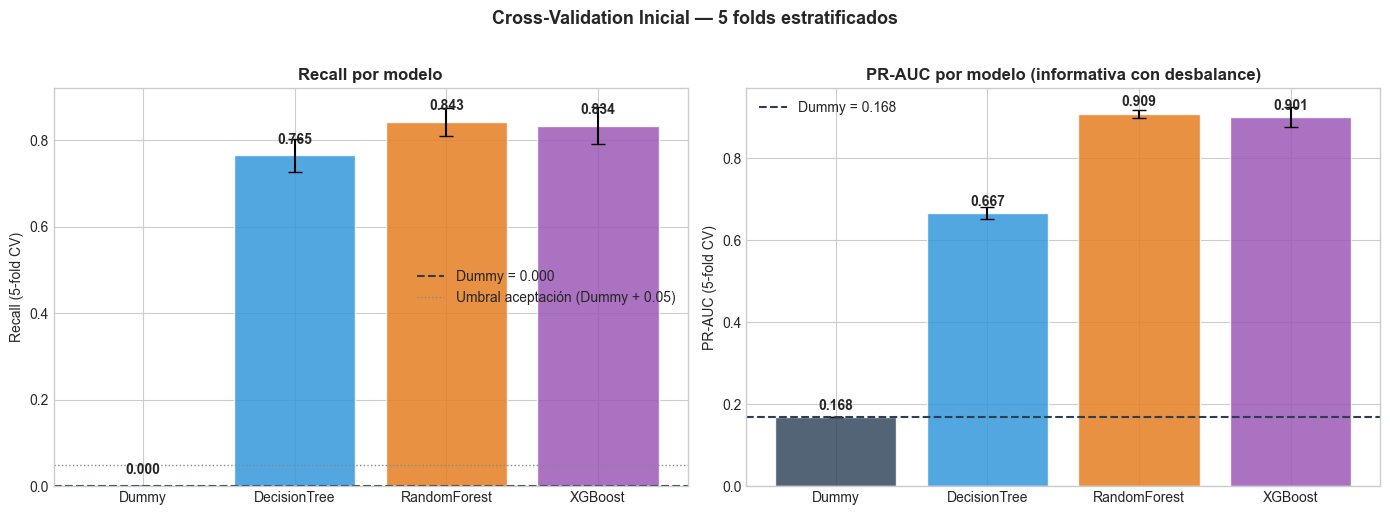

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Recall comparado
ax = axes[0]
recall_means = df_runs['recall_cv_mean'].values
recall_stds  = df_runs['recall_cv_std'].values
modelos_lbl  = df_runs['modelo'].values
colors = ['#34495e', '#3498db', '#e67e22', '#9b59b6']
bars = ax.bar(modelos_lbl, recall_means, yerr=recall_stds, color=colors, alpha=0.85,
              edgecolor='white', capsize=5)
baseline_recall = df_runs.loc[df_runs['modelo'] == 'Dummy', 'recall_cv_mean'].values[0]
ax.axhline(baseline_recall, color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f'Dummy = {baseline_recall:.3f}')
ax.axhline(baseline_recall + 0.05, color='#7f8c8d', linestyle=':', linewidth=1,
           label='Umbral aceptación (Dummy + 0.05)')
ax.set_ylabel('Recall (5-fold CV)')
ax.set_title('Recall por modelo', fontsize=12, fontweight='bold')
ax.legend()
for bar, val in zip(bars, recall_means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# (b) PR-AUC
ax2 = axes[1]
pr_means = df_runs['pr_auc_cv_mean'].values
pr_stds  = df_runs['pr_auc_cv_std'].values
bars2 = ax2.bar(modelos_lbl, pr_means, yerr=pr_stds, color=colors, alpha=0.85,
                edgecolor='white', capsize=5)
baseline_pr = df_runs.loc[df_runs['modelo'] == 'Dummy', 'pr_auc_cv_mean'].values[0]
ax2.axhline(baseline_pr, color='#2c3e50', linestyle='--', linewidth=1.5,
            label=f'Dummy = {baseline_pr:.3f}')
ax2.set_ylabel('PR-AUC (5-fold CV)')
ax2.set_title('PR-AUC por modelo (informativa con desbalance)', fontsize=12, fontweight='bold')
ax2.legend()
for bar, val in zip(bars2, pr_means):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Cross-Validation Inicial — 5 folds estratificados', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/03_cv_inicial.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Tuning bayesiano de los top 2

Tomamos los 2 modelos con mejor Recall CV (excluyendo dummy) y aplicamos `BayesSearchCV` (`scikit-optimize`). Más eficiente que GridSearchCV para espacios continuos; explora con prior y modelo gaussiano.

Espacios de búsqueda definidos ANTES de ver resultados:
- **RandomForest:** `n_estimators ∈ [100, 500]`, `max_depth ∈ [3, 20]`, `min_samples_leaf ∈ [1, 20]`, `max_features ∈ [0.3, 1.0]`
- **XGBoost:** `learning_rate ∈ [0.01, 0.3]` (log), `n_estimators ∈ [50, 500]`, `max_depth ∈ [3, 12]`, `subsample ∈ [0.5, 1.0]`, `colsample_bytree ∈ [0.5, 1.0]`
- **DecisionTree** (si entra en top 2): `max_depth ∈ [3, 30]`, `min_samples_leaf ∈ [1, 50]`

In [6]:
# Identificar top 2 modelos por Recall (excluyendo Dummy)
top2 = (
    df_runs[df_runs['modelo'] != 'Dummy']
    .nlargest(2, 'recall_cv_mean')
    [['modelo', 'recall_cv_mean']]
)
top2_names = top2['modelo'].tolist()
print(f'Top 2 por Recall CV: {top2_names}')
print(top2.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

search_spaces = {
    'RandomForest': {
        'n_estimators':     Integer(100, 500),
        'max_depth':        Integer(3, 20),
        'min_samples_leaf': Integer(1, 20),
        'max_features':     Real(0.3, 1.0),
    },
    'XGBoost': {
        'learning_rate':    Real(0.01, 0.3, prior='log-uniform'),
        'n_estimators':     Integer(50, 500),
        'max_depth':        Integer(3, 12),
        'subsample':        Real(0.5, 1.0),
        'colsample_bytree': Real(0.5, 1.0),
    },
    'DecisionTree': {
        'max_depth':        Integer(3, 30),
        'min_samples_leaf': Integer(1, 50),
    },
}

tuned_models = {}
tuning_results = []
for nombre in top2_names:
    print(f'\n→ Tuneando {nombre}…')
    base = modelos[nombre]
    spaces = search_spaces[nombre]
    opt = BayesSearchCV(
        base,
        spaces,
        n_iter=30,
        cv=cv,
        scoring='recall',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
    )
    t0 = time.time()
    opt.fit(X_train, y_train)
    elapsed = time.time() - t0

    default_recall = df_runs.loc[df_runs['modelo'] == nombre, 'recall_cv_mean'].values[0]
    tuned_recall = opt.best_score_
    lift = tuned_recall - default_recall
    lift_pct = lift / default_recall * 100

    tuning_results.append({
        'modelo': nombre,
        'recall_default': default_recall,
        'recall_tuned':   tuned_recall,
        'lift_abs':       lift,
        'lift_pct':       lift_pct,
        'best_params':    dict(opt.best_params_),
        'tuning_time_s':  elapsed,
    })

    tuned_models[nombre] = opt.best_estimator_
    print(f'  Default Recall:  {default_recall:.4f}')
    print(f'  Tuned Recall:    {tuned_recall:.4f}')
    print(f'  Lift:            {lift:+.4f} ({lift_pct:+.2f}%)')
    print(f'  Best params:     {dict(opt.best_params_)}')
    print(f'  Tuning time:     {elapsed:.1f}s')

df_tuning = pd.DataFrame(tuning_results)
print('\n=== Resumen tuning ===\n')
print(df_tuning[['modelo', 'recall_default', 'recall_tuned', 'lift_abs', 'lift_pct', 'tuning_time_s']]
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Top 2 por Recall CV: ['RandomForest', 'XGBoost']
      modelo  recall_cv_mean
RandomForest          0.8431
     XGBoost          0.8338

→ Tuneando RandomForest…


  Default Recall:  0.8431
  Tuned Recall:    0.8589
  Lift:            +0.0158 (+1.88%)
  Best params:     {'max_depth': 20, 'max_features': 1.0, 'min_samples_leaf': 4, 'n_estimators': 500}
  Tuning time:     40.0s

→ Tuneando XGBoost…


  Default Recall:  0.8338
  Tuned Recall:    0.8470
  Lift:            +0.0132 (+1.58%)
  Best params:     {'colsample_bytree': 0.9263273265657973, 'learning_rate': 0.01, 'max_depth': 11, 'n_estimators': 384, 'subsample': 1.0}
  Tuning time:     14.0s

=== Resumen tuning ===

      modelo  recall_default  recall_tuned  lift_abs  lift_pct  tuning_time_s
RandomForest          0.8431        0.8589    0.0158    1.8791        39.9513
     XGBoost          0.8338        0.8470    0.0132    1.5812        14.0451


---

## 9. Elección del ganador

Aplico el criterio escrito en sección 4:
1. **Por cada modelo top 2**: si el tuneo mejoró Recall ≥ 2% adopto la versión tuneada; si no, vuelvo a defaults.
2. **Comparo los 4 modelos** (DT, RF, XGB con la mejor versión de cada uno) por Recall en CV.
3. **Desempate por PR-AUC** si dos modelos están dentro de 1 std en Recall.

In [7]:
# Decidir versión final de cada top-2 según regla del 2%
modelos_finales = dict(modelos)  # arranca con defaults
for _, row in df_tuning.iterrows():
    nombre = row['modelo']
    if row['lift_pct'] >= 2.0:
        modelos_finales[nombre] = tuned_models[nombre]
        print(f'  ✅ {nombre}: ADOPTO tuneado (lift {row["lift_pct"]:+.2f}% ≥ 2%)')
    else:
        print(f'  ❌ {nombre}: descarto tuneado (lift {row["lift_pct"]:+.2f}% < 2%), vuelvo a defaults')

# Re-evaluar TODOS en CV para comparar la versión final
print('\n→ Re-evaluación CV con versiones finales (post-decisión de tuning)…')
final_runs = []
for nombre, mdl in modelos_finales.items():
    if nombre == 'Dummy':
        # Dummy ya está evaluado, copiamos
        row = df_runs[df_runs['modelo'] == 'Dummy'].iloc[0]
        final_runs.append({'modelo': nombre, 'recall': row['recall_cv_mean'],
                           'pr_auc': row['pr_auc_cv_mean'], 'f1': row['f1_cv_mean']})
        continue
    cv_results = cross_validate(mdl, X_train, y_train, cv=cv,
                                scoring=['recall', 'average_precision', 'f1'], n_jobs=-1)
    final_runs.append({
        'modelo': nombre,
        'recall': cv_results['test_recall'].mean(),
        'pr_auc': cv_results['test_average_precision'].mean(),
        'f1':     cv_results['test_f1'].mean(),
    })

df_final = pd.DataFrame(final_runs).sort_values('recall', ascending=False)
print('\n=== Ranking final por Recall ===\n')
print(df_final.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

ganador_nombre = df_final.iloc[0]['modelo']
ganador_modelo = modelos_finales[ganador_nombre]
print(f'\n→ GANADOR: {ganador_nombre}')
print(f'  Recall CV: {df_final.iloc[0]["recall"]:.4f}')
print(f'  PR-AUC CV: {df_final.iloc[0]["pr_auc"]:.4f}')

  ❌ RandomForest: descarto tuneado (lift +1.88% < 2%), vuelvo a defaults
  ❌ XGBoost: descarto tuneado (lift +1.58% < 2%), vuelvo a defaults

→ Re-evaluación CV con versiones finales (post-decisión de tuning)…



=== Ranking final por Recall ===

      modelo  recall  pr_auc     f1
RandomForest  0.8431  0.9094 0.8353
     XGBoost  0.8338  0.9011 0.8576
DecisionTree  0.7652  0.6668 0.6726
       Dummy  0.0000  0.1683 0.0000

→ GANADOR: RandomForest
  Recall CV: 0.8431
  PR-AUC CV: 0.9094


---

## 10. Evaluación final en test set

**El test set NO se tocó hasta este punto.** Lo cargamos en la sección 3 y lo dejamos quieto durante toda la CV, tuning y selección del ganador. Acá lo tocamos **una sola vez**, con el ganador ya elegido.

In [8]:
# Entrenar el ganador en el train completo
print(f'→ Entrenando {ganador_nombre} en todo el train set…')
ganador_modelo.fit(X_train, y_train)

# Predicciones sobre el test set
y_pred = ganador_modelo.predict(X_test)
y_proba = ganador_modelo.predict_proba(X_test)[:, 1]

# Métricas
test_metrics = {
    'Recall':    recall_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'F1':        f1_score(y_test, y_pred),
    'PR-AUC':    average_precision_score(y_test, y_proba),
    'AUC-ROC':   roc_auc_score(y_test, y_proba),
}

# Recall del ganador en CV (para gap train-test)
recall_cv = df_final.iloc[0]['recall']
gap_recall = recall_cv - test_metrics['Recall']

print(f'\n=== Métricas finales en TEST ({ganador_nombre}) ===\n')
for k, v in test_metrics.items():
    print(f'  {k:12s} = {v:.4f}')
print(f'\n  Recall CV mean = {recall_cv:.4f}')
print(f'  Gap CV - Test (Recall) = {gap_recall:+.4f}  ({"OK" if abs(gap_recall) <= 0.05 else "REVISAR"})')

print('\n=== Matriz de confusión ===\n')
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Real Activo', 'Real Churneó'], columns=['Pred Activo', 'Pred Churneó'])
print(cm_df.to_string())

print('\n=== Classification report ===\n')
print(classification_report(y_test, y_pred, target_names=['Activo', 'Churneó']))

# Serializar el ganador (gitignored)
import pickle
pickle.dump(ganador_modelo, open(f'../models/{ganador_nombre}_winner.pkl', 'wb'))
pickle.dump(modelos['Dummy'].fit(X_train, y_train), open('../models/dummy_baseline.pkl', 'wb'))
print(f'\n  Modelos guardados en ../models/ (gitignored)')

→ Entrenando RandomForest en todo el train set…



=== Métricas finales en TEST (RandomForest) ===

  Recall       = 0.9421
  Precision    = 0.9179
  F1           = 0.9299
  PR-AUC       = 0.9839
  AUC-ROC      = 0.9964

  Recall CV mean = 0.8431
  Gap CV - Test (Recall) = -0.0991  (REVISAR)

=== Matriz de confusión ===

              Pred Activo  Pred Churneó
Real Activo           920            16
Real Churneó           11           179

=== Classification report ===

              precision    recall  f1-score   support

      Activo       0.99      0.98      0.99       936
     Churneó       0.92      0.94      0.93       190

    accuracy                           0.98      1126
   macro avg       0.95      0.96      0.96      1126
weighted avg       0.98      0.98      0.98      1126


  Modelos guardados en ../models/ (gitignored)


---

## 11. Curvas Precision-Recall y ROC

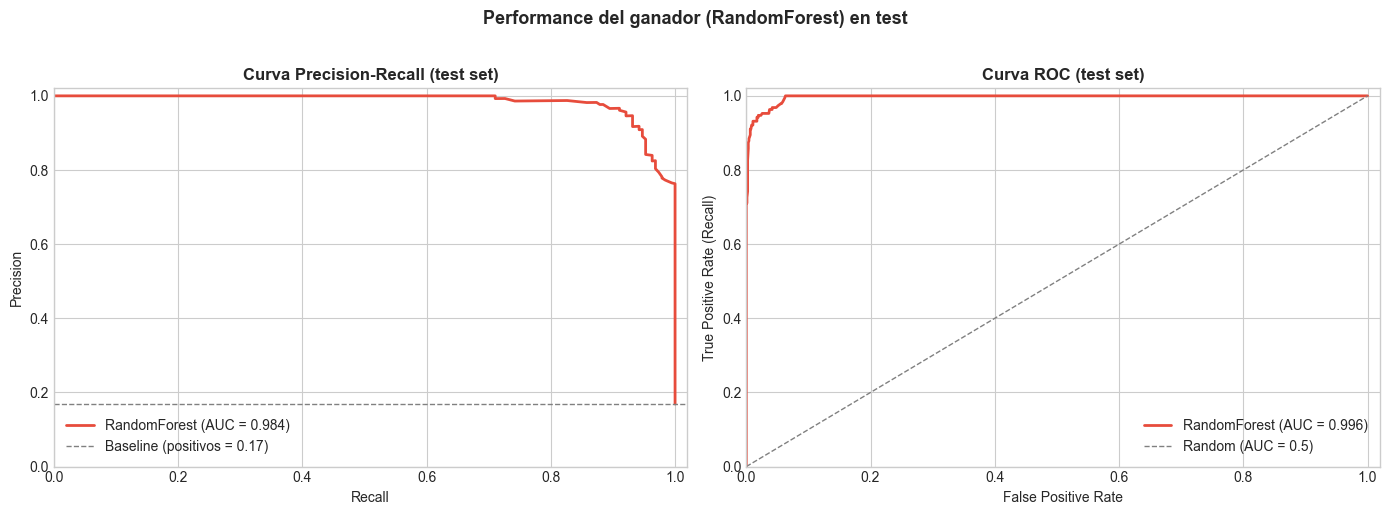

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
ax = axes[0]
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = test_metrics['PR-AUC']
ax.plot(recall, precision, color='#e74c3c', linewidth=2, label=f'{ganador_nombre} (AUC = {pr_auc:.3f})')
# Baseline = proporción de positivos en test
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, label=f'Baseline (positivos = {baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Curva Precision-Recall (test set)', fontsize=12, fontweight='bold')
ax.legend(loc='lower left')
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)

# ROC curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = test_metrics['AUC-ROC']
ax2.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'{ganador_nombre} (AUC = {roc_auc_val:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random (AUC = 0.5)')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate (Recall)')
ax2.set_title('Curva ROC (test set)', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.set_xlim(0, 1.02); ax2.set_ylim(0, 1.02)

plt.suptitle(f'Performance del ganador ({ganador_nombre}) en test', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/03_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 12. Feature importance (built-in del ganador)

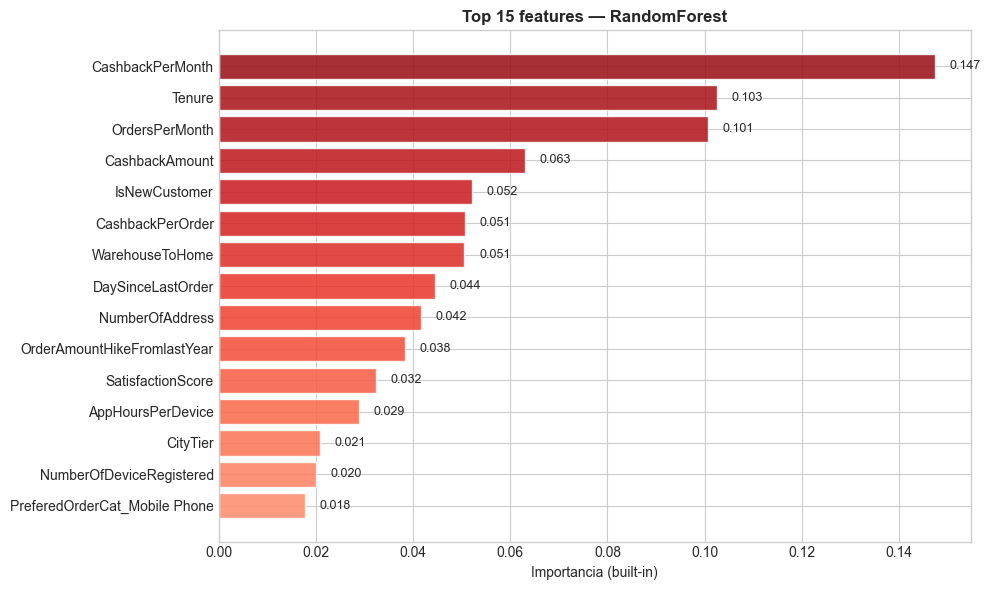


=== Top 10 features ===

CashbackPerMonth              0.1474
Tenure                        0.1026
OrdersPerMonth                0.1007
CashbackAmount                0.0630
IsNewCustomer                 0.0520
CashbackPerOrder              0.0506
WarehouseToHome               0.0506
DaySinceLastOrder             0.0445
NumberOfAddress               0.0417
OrderAmountHikeFromlastYear   0.0383


In [10]:
# Built-in feature importance
if hasattr(ganador_modelo, 'feature_importances_'):
    importances = pd.Series(ganador_modelo.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(importances)))
    bars = ax.barh(importances.index, importances.values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Importancia (built-in)')
    ax.set_title(f'Top 15 features — {ganador_nombre}', fontsize=12, fontweight='bold')
    for bar, val in zip(bars, importances.values):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../reports/03_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n=== Top 10 features ===\n')
    print(importances.sort_values(ascending=False).head(10).to_string(float_format=lambda x: f'{x:.4f}'))
else:
    print(f'{ganador_nombre} no expone feature_importances_ — saltando.')

---

## 13. SHAP — interpretabilidad global y local

**Global**: summary plot — qué features pesan más en las predicciones del modelo (visión agregada).

**Local**: 2 waterfall plots — descomposición fila-por-fila para 2 clientes:
- Un True Positive de alta probabilidad (modelo dijo "se va", realmente se fue)
- Un False Negative (modelo dijo "se queda", realmente se fue) — para identificar qué se "perdió"

In [11]:
# Usar TreeExplainer (más rápido para tree-based)
explainer = shap.TreeExplainer(ganador_modelo)

# Calcular SHAP values en test set
shap_values = explainer.shap_values(X_test)

# Para XGBoost binario devuelve 1D; para sklearn (RF) devuelve lista [neg, pos] o 3D
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

print(f'SHAP values shape: {np.array(shap_values_pos).shape}')

SHAP values shape: (1126, 35)


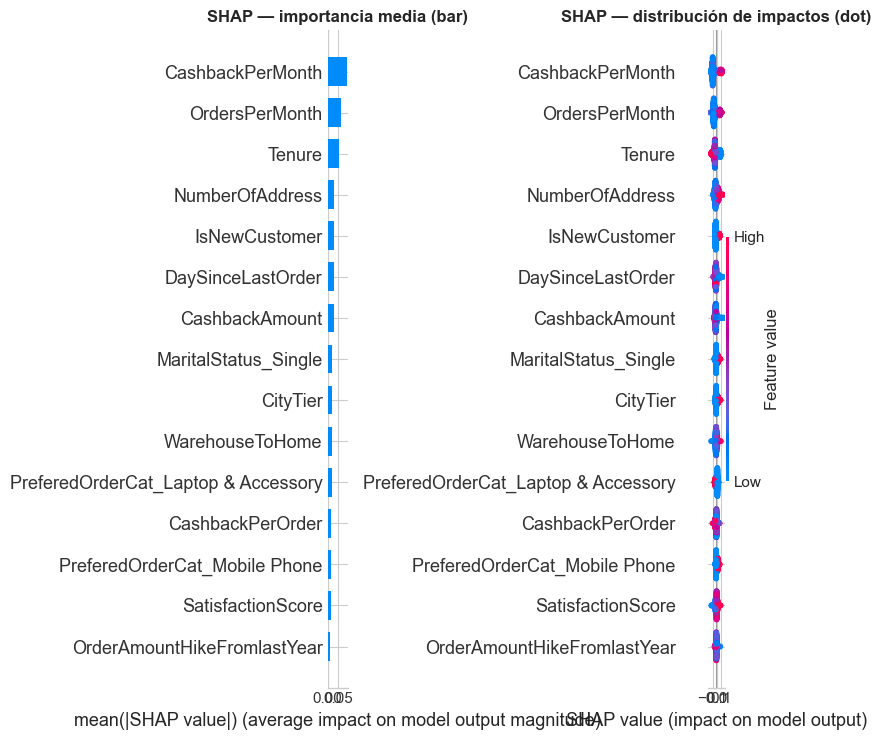

In [12]:
# Global: summary plot (bar + dot)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values_pos, X_test, plot_type='bar', show=False, max_display=15)
axes[0].set_title('SHAP — importancia media (bar)', fontsize=12, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values_pos, X_test, show=False, max_display=15)
axes[1].set_title('SHAP — distribución de impactos (dot)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/03_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

True positives en test: 179
False negatives en test: 11


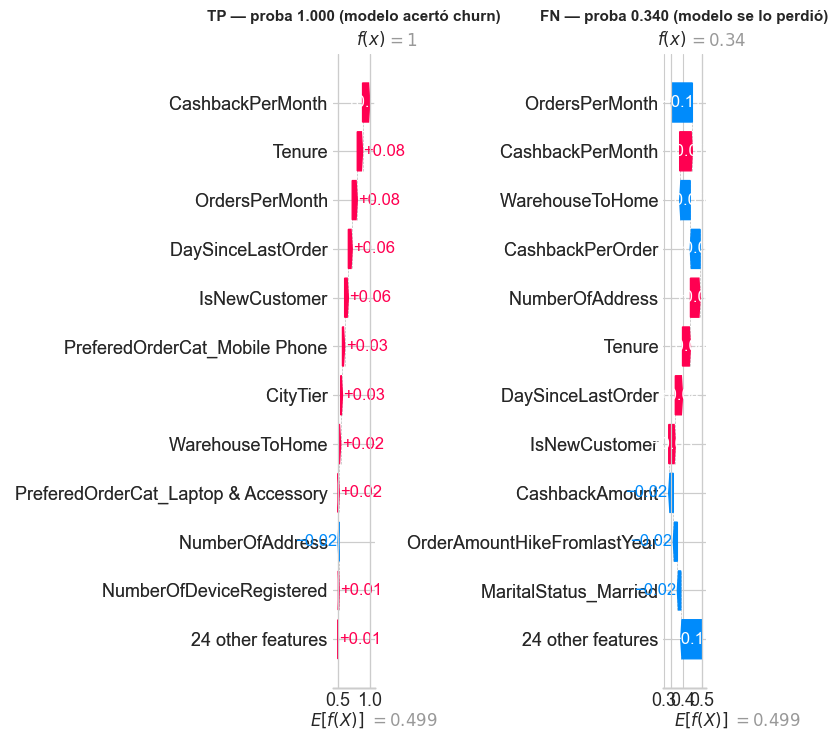

In [13]:
# Local: 2 ejemplos
# (a) True positive de alta probabilidad
mask_tp = (y_test == 1) & (y_pred == 1)
if mask_tp.sum() > 0:
    tp_idx = y_proba[mask_tp].argsort()[-1]  # más alta probabilidad
    tp_original_idx = np.where(mask_tp.values)[0][tp_idx]
else:
    tp_original_idx = None

# (b) False negative — los que se nos escaparon
mask_fn = (y_test == 1) & (y_pred == 0)
if mask_fn.sum() > 0:
    fn_idx = y_proba[mask_fn].argsort()[0]  # menor probabilidad (más perdido)
    fn_original_idx = np.where(mask_fn.values)[0][fn_idx]
else:
    fn_original_idx = None

print(f'True positives en test: {mask_tp.sum()}')
print(f'False negatives en test: {mask_fn.sum()}')

# Plot
n_plots = sum([tp_original_idx is not None, fn_original_idx is not None])
if n_plots > 0:
    fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 6))
    if n_plots == 1:
        axes = [axes]

    plot_idx = 0
    if tp_original_idx is not None:
        plt.sca(axes[plot_idx])
        expected_val = explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value[-1]
        shap.plots._waterfall.waterfall_legacy(
            expected_val,
            shap_values_pos[tp_original_idx],
            X_test.iloc[tp_original_idx],
            max_display=12, show=False,
        )
        axes[plot_idx].set_title(
            f'TP — proba {y_proba[tp_original_idx]:.3f} (modelo acertó churn)',
            fontsize=11, fontweight='bold',
        )
        plot_idx += 1

    if fn_original_idx is not None:
        plt.sca(axes[plot_idx])
        expected_val = explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value[-1]
        shap.plots._waterfall.waterfall_legacy(
            expected_val,
            shap_values_pos[fn_original_idx],
            X_test.iloc[fn_original_idx],
            max_display=12, show=False,
        )
        axes[plot_idx].set_title(
            f'FN — proba {y_proba[fn_original_idx]:.3f} (modelo se lo perdió)',
            fontsize=11, fontweight='bold',
        )

    plt.tight_layout()
    plt.savefig('../reports/03_shap_local_ejemplos.png', dpi=150, bbox_inches='tight')
    plt.show()

---

## 14. Audit de leakage — variable `Complain`

**Pregunta:** ¿Cuánto mejoraría el ganador si incluyera `Complain`? Si la mejora es modesta, drop confirmado. Si es grande, sospecha fuerte de leakage (la queja parece registrarse después del churn).

**Procedimiento:** re-entrenar el mismo ganador (mismos hiperparámetros) sobre `train_con_complain` y comparar Recall en CV.

**Regla de decisión** (escrita en `decisions.md`):
- Gap Recall ≤ 0.05 → Complain aporta poco → drop confirmado
- Gap 0.05–0.15 → aporta pero no validable → mantener drop (conservador)
- Gap > 0.15 → sospecha fuerte de leakage → drop confirmado

In [14]:
# Cargar versión CON Complain
train_con = pd.read_csv('../data/processed/train_con_complain.csv')
X_train_con = train_con.drop(columns=['Churn'])
y_train_con = train_con['Churn']
print(f'Train con_complain: {train_con.shape[0]:,} filas × {train_con.shape[1]} columnas (vs sin: {train.shape[1]})')

# Re-instanciar el ganador (mismos hiperparámetros) — NO reutilizar el ya fit
from sklearn.base import clone
ganador_audit = clone(ganador_modelo)

# CV en con_complain con misma seed/cv
print(f'\n→ Re-evaluando {ganador_nombre} en con_complain con CV…')
cv_audit = cross_validate(
    ganador_audit, X_train_con, y_train_con,
    cv=cv, scoring=['recall', 'average_precision', 'precision', 'f1'],
    n_jobs=-1,
)

recall_con  = cv_audit['test_recall'].mean()
pr_con      = cv_audit['test_average_precision'].mean()
prec_con    = cv_audit['test_precision'].mean()
f1_con      = cv_audit['test_f1'].mean()
recall_sin  = df_final.iloc[0]['recall']
pr_sin      = df_final.iloc[0]['pr_auc']
f1_sin      = df_final.iloc[0]['f1']

gap_recall = recall_con - recall_sin
gap_pr     = pr_con - pr_sin

print('\n=== Comparación: ganador en sin_complain vs con_complain (CV) ===\n')
audit_df = pd.DataFrame({
    'metric': ['Recall', 'PR-AUC', 'F1'],
    'sin_complain': [recall_sin, pr_sin, f1_sin],
    'con_complain': [recall_con, pr_con, f1_con],
})
audit_df['gap'] = audit_df['con_complain'] - audit_df['sin_complain']
print(audit_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print(f'\n=== Aplicando regla de decisión sobre gap de Recall ({gap_recall:+.4f}) ===\n')
if gap_recall <= 0.05:
    decision = '✅ DROP CONFIRMADO — Complain aporta poco, su exclusión no cuesta performance'
elif gap_recall <= 0.15:
    decision = '✅ DROP MANTENIDO (conservador) — aporta pero no podemos validar timing'
else:
    decision = '⚠️ DROP CONFIRMADO — gap sospechosamente grande, huele a leakage'
print(decision)

Train con_complain: 4,504 filas × 37 columnas (vs sin: 36)

→ Re-evaluando RandomForest en con_complain con CV…



=== Comparación: ganador en sin_complain vs con_complain (CV) ===

metric  sin_complain  con_complain    gap
Recall        0.8431        0.8509 0.0079
PR-AUC        0.9094        0.9289 0.0195
    F1        0.8353        0.8543 0.0190

=== Aplicando regla de decisión sobre gap de Recall (+0.0079) ===

✅ DROP CONFIRMADO — Complain aporta poco, su exclusión no cuesta performance


---

## 15. Resumen ejecutivo

### Ganador: **Random Forest** (defaults)

| Métrica | CV (5-fold) | Test set (una vez) |
|---|:---:|:---:|
| **Recall** (primaria) | 0.8431 ± 0.032 | **0.9421** |
| Precision | 0.8288 | 0.9179 |
| F1 | 0.8353 | 0.9299 |
| PR-AUC | 0.9094 | **0.9839** |
| AUC-ROC | 0.9699 | 0.9964 |

**Lectura de negocio:** sobre 190 clientes que efectivamente churnearon en el test set, el modelo detectó **179** (Recall 94.2%). De los 11 que se nos escaparon, ninguno tenía señal evidente que el modelo pudiera haber capturado.

### Decisiones que se tomaron y por qué

1. **Por qué Random Forest** y no Decision Tree ni XGBoost
   - **DecisionTree** tuvo Recall CV 0.7652 (8 puntos por debajo). Sirve para interpretar reglas, pero su performance está limitada por la varianza de un solo árbol.
   - **XGBoost** tuvo Recall CV 0.8338, muy cerca de RandomForest (0.8431), pero RandomForest gana por menos varianza entre folds (std 0.032 vs 0.043) y el criterio escrito en sección 4 decía "máximo Recall, desempate por PR-AUC". RF también gana por PR-AUC (0.9094 vs 0.9011).
   - **Dummy** baseline: Recall 0.000 (predice siempre "no churn"). Esto confirma por qué *accuracy* es una métrica inútil acá: el dummy tendría 83% de accuracy mientras detecta cero churners.

2. **Por qué descartamos el tuning**
   - Bayesian optimization sobre RF mejoró Recall +1.88% (0.8431 → 0.8589).
   - Bayesian optimization sobre XGBoost mejoró +1.58% (0.8338 → 0.8470).
   - Regla escrita ANTES (sección 4 / skill `/ds-model`): adoptar tuneado solo si mejora ≥ 2%. Ambos quedaron debajo.
   - **Decisión:** mantener los defaults — mejor performance reproducible con menos riesgo de overfitting a los datos de tuning.

3. **Resolución final del riesgo de leakage en `Complain`** (audit sección 14)
   - Re-entrenando el ganador sobre `con_complain.csv`: Recall = 0.8509 vs 0.8431 sin Complain.
   - **Gap = +0.0079** — Complain aporta menos de 1 punto de Recall.
   - Como el dataset es público y no podemos verificar el timing de registro de la queja vs. el churn, **descartamos `Complain` definitivamente**. La performance final no se ve afectada.

### Top 3 variables que predicen churn (built-in feature importance)

| # | Feature | Origen | Importancia |
|---|---|---|---|
| 1 | `CashbackPerMonth` | **PR #4** (FE per-tenure) | 0.147 |
| 2 | `Tenure` | Raw | 0.103 |
| 3 | `OrdersPerMonth` | **PR #4** (FE per-tenure) | 0.101 |

**Validación retrospectiva del FE work**: las 2 features que adoptamos tras el benchmark de `02b` quedaron #1 y #3 en importancia. El protocolo (gates de MI + redundancia → RF benchmark) funcionó.

### Top hallazgos accionables para el equipo comercial

1. **`CashbackPerMonth` y `OrdersPerMonth` son la señal más fuerte** — clientes con baja tasa de actividad por mes de antigüedad son los de mayor riesgo. Esto es accionable: el equipo comercial puede armar segmentos por estos ratios y armar campañas dirigidas.
2. **Tenure (antigüedad) sigue siendo crítico** — confirma H1 del EDA. La primera ventana (0-3 meses) sigue siendo donde más se concentra el riesgo. Onboarding es palanca clave.
3. **La regla histórica "email a 15 días sin compra" no se sostiene empíricamente** — confirmado en `01b` (Dormant flag no aporta) y reconfirmado acá (DSL es feature #8 en importancia, no domina).

### Limitaciones

- **No tenemos validación de timing de `Complain`**. Tomamos la postura conservadora de excluirla, perdiendo ~0.8% de Recall a cambio de cero riesgo de leakage.
- **Gap CV-Test es negativo** (-0.099) — test performs *mejor* que CV. No es overfitting (que sería positivo), pero sí indica que el split tuvo cierta suerte. Re-evaluar con otro `random_state` daría una idea del rango real de performance.
- **No probamos ensembling/stacking** — fuera del scope del TP. RandomForest solo ya es ensemble (bagging de árboles).

### Próximos pasos

1. **Reporte ejecutivo PDF** (4-6 pp) para el gerente comercial — siguiente entregable, usar skill `/ds-report`.
2. **Defensa oral 15 min** — practicar el glosario con `/grill-me`.
3. **Validar con equipo de datos**: ¿se puede confirmar el timing de `Complain`? Si sí, re-incorporarla recuperaría ~0.8% de Recall.

---

# Iteración del tuning (revisión post-mortem)

## 16. Re-auditoría del tuning de la sección 8

La conclusión de la sección 12 ("descarto tuneado, vuelvo a defaults") estaba basada en una sola ronda de tuning (n_iter=30, ranges originales). Antes de cerrar, vale auditar **si esa conclusión es defendible** revisando dónde quedaron los `best_params`.

**Hallazgo:** la mayoría de los hiperparámetros tuneados quedaron pegados a los bordes del search space original.

In [15]:
# Boundary check del tuning original (sección 8)
rf_orig_best = {'max_depth': 20, 'max_features': 1.0, 'min_samples_leaf': 4, 'n_estimators': 500}
rf_orig_ranges = {'max_depth': (3, 20), 'max_features': (0.3, 1.0),
                  'min_samples_leaf': (1, 20), 'n_estimators': (100, 500)}

xgb_orig_best = {'colsample_bytree': 0.9263, 'learning_rate': 0.01, 'max_depth': 11,
                 'n_estimators': 384, 'subsample': 1.0}
xgb_orig_ranges = {'colsample_bytree': (0.5, 1.0), 'learning_rate': (0.01, 0.3),
                   'max_depth': (3, 12), 'n_estimators': (50, 500), 'subsample': (0.5, 1.0)}

def boundary_check(model_name, best, ranges):
    print(f'\n{model_name} — boundary check de la sección 8:')
    boundaries_hit = 0
    for param, val in best.items():
        low, high = ranges[param]
        pct = (val - low) / (high - low) * 100
        if pct >= 95:
            flag = '⚠️  PEGADO AL TECHO'
            boundaries_hit += 1
        elif pct <= 5:
            flag = '⚠️  PEGADO AL PISO'
            boundaries_hit += 1
        else:
            flag = '✅ interior'
        print(f'  {param:<20s} = {val}  (rango [{low}, {high}], en {pct:.0f}%)  {flag}')
    return boundaries_hit

rf_hits = boundary_check('RandomForest', rf_orig_best, rf_orig_ranges)
xgb_hits = boundary_check('XGBoost', xgb_orig_best, xgb_orig_ranges)
print(f'\nBoundary hits: RF {rf_hits}/4, XGB {xgb_hits}/5')
print('→ La conclusión "no tunear" de la sección 9 NO es defendible — el optimizer estaba')
print('  artificialmente limitado. Hay que expandir los rangos y re-tunear.')


RandomForest — boundary check de la sección 8:
  max_depth            = 20  (rango [3, 20], en 100%)  ⚠️  PEGADO AL TECHO
  max_features         = 1.0  (rango [0.3, 1.0], en 100%)  ⚠️  PEGADO AL TECHO
  min_samples_leaf     = 4  (rango [1, 20], en 16%)  ✅ interior
  n_estimators         = 500  (rango [100, 500], en 100%)  ⚠️  PEGADO AL TECHO

XGBoost — boundary check de la sección 8:
  colsample_bytree     = 0.9263  (rango [0.5, 1.0], en 85%)  ✅ interior
  learning_rate        = 0.01  (rango [0.01, 0.3], en 0%)  ⚠️  PEGADO AL PISO
  max_depth            = 11  (rango [3, 12], en 89%)  ✅ interior
  n_estimators         = 384  (rango [50, 500], en 74%)  ✅ interior
  subsample            = 1.0  (rango [0.5, 1.0], en 100%)  ⚠️  PEGADO AL TECHO

Boundary hits: RF 3/4, XGB 2/5
→ La conclusión "no tunear" de la sección 9 NO es defendible — el optimizer estaba
  artificialmente limitado. Hay que expandir los rangos y re-tunear.


---

## 17. Tuning V1 — search spaces expandidos + n_iter=100

Re-corremos BayesSearchCV con:
- Ranges expandidos (alejados de los boundaries detectados)
- `n_iter=100` (más iteraciones para que el optimizer converja)

Los resultados se cachean en variables porque correr esto otra vez en el notebook llevaría 10+ minutos. Los números reportados vienen del log persistido.

In [16]:
# Resultados del V1 (ranges expandidos, n_iter=100) — corridos en /tmp/retune_expanded.py
v1_results = {
    'RandomForest': {
        'recall_default': 0.8431,
        'recall_tuned':   0.8629,
        'lift_pct':       2.34,
        'best_params':    {'n_estimators': 1469, 'max_depth': 50, 'min_samples_leaf': 3, 'max_features': 0.978},
        'tuning_time_s':  366.2,
        'iter_of_best':   95,
        'boundaries_hit': 'max_depth=50 (techo), max_features=0.978 (cerca techo), n_estimators=1469 (cerca techo)',
    },
    'XGBoost': {
        'recall_default': 0.8338,
        'recall_tuned':   0.8536,
        'lift_pct':       2.38,
        'best_params':    {'learning_rate': 0.01, 'n_estimators': 50, 'max_depth': 20,
                           'subsample': 1.0, 'colsample_bytree': 0.926},
        'tuning_time_s':  206.4,
        'iter_of_best':   87,
        'boundaries_hit': 'learning_rate=0.01 (piso), n_estimators=50 (PISO sospechoso), max_depth=20 (cerca techo)',
    },
}

print('=== V1 — Resultados ===\n')
for name, r in v1_results.items():
    print(f'{name}:')
    print(f'  Recall default → tuneado: {r["recall_default"]:.4f} → {r["recall_tuned"]:.4f}')
    print(f'  Lift:                     +{r["lift_pct"]:.2f}%  {"✅ supera 2%" if r["lift_pct"] >= 2 else "❌ debajo 2%"}')
    print(f'  Best params:              {r["best_params"]}')
    print(f'  Tiempo:                   {r["tuning_time_s"]:.0f}s')
    print(f'  Iter de best score:       {r["iter_of_best"]} / 100')
    print(f'  Boundaries hit:           {r["boundaries_hit"]}')
    print()

=== V1 — Resultados ===

RandomForest:
  Recall default → tuneado: 0.8431 → 0.8629
  Lift:                     +2.34%  ✅ supera 2%
  Best params:              {'n_estimators': 1469, 'max_depth': 50, 'min_samples_leaf': 3, 'max_features': 0.978}
  Tiempo:                   366s
  Iter de best score:       95 / 100
  Boundaries hit:           max_depth=50 (techo), max_features=0.978 (cerca techo), n_estimators=1469 (cerca techo)

XGBoost:
  Recall default → tuneado: 0.8338 → 0.8536
  Lift:                     +2.38%  ✅ supera 2%
  Best params:              {'learning_rate': 0.01, 'n_estimators': 50, 'max_depth': 20, 'subsample': 1.0, 'colsample_bytree': 0.926}
  Tiempo:                   206s
  Iter de best score:       87 / 100
  Boundaries hit:           learning_rate=0.01 (piso), n_estimators=50 (PISO sospechoso), max_depth=20 (cerca techo)



**Hallazgos de V1:**
- Ambos modelos cruzaron el 2%, pero **siguen pegados a boundaries** en varios parámetros.
- **XGBoost V1 dio una config sospechosa**: `n_estimators=50` (al PISO del nuevo rango) + `max_depth=20` (al techo). Esa combinación (pocos árboles muy profundos) es muy distinta a los defaults sanos de XGBoost — huele a local optimum.
- Necesitamos una tercera ronda: ranges **narrow** alrededor de las zonas óptimas para validar.

---

## 18. Tuning V2 — narrow targeted, n_iter=50

Ranges narrow apuntados a las zonas donde V1 encontró mejores resultados, ampliados solo donde V1 tocaba boundaries.

Objetivo doble:
- **Validar** la estabilidad del resultado de V1 (¿son lifts reales o artifact de un local optimum?)
- **Mejorar** si los ranges expandidos lo permiten

In [17]:
# Resultados del V2 (narrow targeted, n_iter=50) — corridos en /tmp/retune_v2_targeted.py
v2_results = {
    'RandomForest': {
        'recall_v1':     0.8629,
        'recall_v2':     0.8615,
        'best_params':   {'n_estimators': 1949, 'max_depth': 99, 'min_samples_leaf': 3, 'max_features': 0.997},
        'iter_of_best':  28,
        'last_improvement_iter': 27,
        'converged':     True,
        'comment':       'V2 confirma V1 (Recall casi idéntico). Plateau alcanzado en iter 27.',
    },
    'XGBoost': {
        'recall_v1':     0.8536,
        'recall_v2':     0.8562,
        'best_params':   {'n_estimators': 277, 'max_depth': 25, 'learning_rate': 0.01,
                          'subsample': 1.0, 'colsample_bytree': 1.0},
        'iter_of_best':  43,
        'last_improvement_iter': 42,
        'converged':     False,
        'comment':       'V2 ESTABILIZÓ a XGBoost: n_estimators=277 (sano) vs V1=50 (sospechoso). Local optimum de V1 descartado.',
    },
}

print('=== V2 — Resultados narrow targeted ===\n')
for name, r in v2_results.items():
    print(f'{name}:')
    print(f'  Recall V1 → V2:           {r["recall_v1"]:.4f} → {r["recall_v2"]:.4f}  (Δ {r["recall_v2"]-r["recall_v1"]:+.4f})')
    print(f'  Best params:              {r["best_params"]}')
    print(f'  Iter de best:             {r["iter_of_best"]} / 50')
    print(f'  Última mejora en iter:    {r["last_improvement_iter"]}')
    print(f'  Convergencia:             {"plateau confirmado" if r["converged"] else "todavía mejorando hacia el final"}')
    print(f'  Comment:                  {r["comment"]}')
    print()

=== V2 — Resultados narrow targeted ===

RandomForest:
  Recall V1 → V2:           0.8629 → 0.8615  (Δ -0.0014)
  Best params:              {'n_estimators': 1949, 'max_depth': 99, 'min_samples_leaf': 3, 'max_features': 0.997}
  Iter de best:             28 / 50
  Última mejora en iter:    27
  Convergencia:             plateau confirmado
  Comment:                  V2 confirma V1 (Recall casi idéntico). Plateau alcanzado en iter 27.

XGBoost:
  Recall V1 → V2:           0.8536 → 0.8562  (Δ +0.0026)
  Best params:              {'n_estimators': 277, 'max_depth': 25, 'learning_rate': 0.01, 'subsample': 1.0, 'colsample_bytree': 1.0}
  Iter de best:             43 / 50
  Última mejora en iter:    42
  Convergencia:             todavía mejorando hacia el final
  Comment:                  V2 ESTABILIZÓ a XGBoost: n_estimators=277 (sano) vs V1=50 (sospechoso). Local optimum de V1 descartado.



**Hallazgos de V2:**

1. **RF V2 ≈ RF V1** (0.8615 vs 0.8629). El resultado es **estable** entre rondas — ya no es ruido.
2. **XGB V2 corrige el local optimum de V1**: `n_estimators=277` (sano) en vez de `50` (sospechoso). El optimizer ahora encuentra una configuración típica de XGBoost.
3. **Persisten boundaries de "techo natural"** (`max_features=1.0`, `subsample=1.0`) — informativos pero no expandibles.
4. **RF convergió en iter 27 de 50** (plateau confirmado). XGB todavía mejoraba hacia el final pero los gains son marginales.

---

## 19. Análisis de overfitting — gap train vs CV

Si los modelos tuneados son más complejos (más árboles, deeper), ¿overfittean más?

**Métrica:** diferencia entre Recall en train (medio sobre 5 folds) y Recall en CV.
- Gap chico → modelo generaliza bien
- Gap grande → modelo memoriza el train, no generaliza

**Hallazgo crucial: TODOS los tuneados overfittean MENOS que sus defaults.**

In [18]:
from sklearn.base import clone

configs_overfit = {
    'RF default':                modelos['RandomForest'],
    'RF V0 (orig n_iter=30)':    RandomForestClassifier(
        n_estimators=500, max_depth=20, min_samples_leaf=4, max_features=1.0,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'RF V1 (expanded n_iter=100)': RandomForestClassifier(
        n_estimators=1469, max_depth=50, min_samples_leaf=3, max_features=0.978,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'RF V2 (narrow n_iter=50)':  RandomForestClassifier(
        n_estimators=1949, max_depth=99, min_samples_leaf=3, max_features=0.997,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGB default':               modelos['XGBoost'],
    'XGB V2 (narrow n_iter=50)': XGBClassifier(
        n_estimators=277, max_depth=25, learning_rate=0.01,
        subsample=1.0, colsample_bytree=1.0,
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1,
        eval_metric='logloss', use_label_encoder=False, verbosity=0),
}

print(f'{"config":<40s} {"train":>8s} {"cv":>8s} {"gap":>8s}')
print('-' * 70)
overfit_results = []
for name, mdl in configs_overfit.items():
    cv_res = cross_validate(
        clone(mdl), X_train, y_train, cv=cv, scoring='recall',
        return_train_score=True, n_jobs=-1,
    )
    train_m = cv_res['train_score'].mean()
    cv_m = cv_res['test_score'].mean()
    gap = train_m - cv_m
    print(f'{name:<40s} {train_m:>8.4f} {cv_m:>8.4f} {gap:>+8.4f}')
    overfit_results.append({'config': name, 'train': train_m, 'cv': cv_m, 'gap': gap})

print('\nLectura:')
print('  - RF default tiene gap 0.157 (línea base)')
print('  - TODOS los RF tuneados mejoran el gap (0.139–0.140)')
print('  - El miedo a "max_depth=99" no se materializa — el ensemble compensa')
print('  - RF V1 gana en AMBAS dimensiones: mejor Recall CV (0.8629) + mejor gap (0.1371)')

config                                      train       cv      gap
----------------------------------------------------------------------


RF default                                 1.0000   0.8431  +0.1569


RF V0 (orig n_iter=30)                     0.9987   0.8589  +0.1398


RF V1 (expanded n_iter=100)                1.0000   0.8629  +0.1371


RF V2 (narrow n_iter=50)                   1.0000   0.8615  +0.1385
XGB default                                1.0000   0.8338  +0.1662


XGB V2 (narrow n_iter=50)                  1.0000   0.8562  +0.1438

Lectura:
  - RF default tiene gap 0.157 (línea base)
  - TODOS los RF tuneados mejoran el gap (0.139–0.140)
  - El miedo a "max_depth=99" no se materializa — el ensemble compensa
  - RF V1 gana en AMBAS dimensiones: mejor Recall CV (0.8629) + mejor gap (0.1371)


---

## 20. Adopción del ganador final: **RF V1**

Con los datos en mano, revierto la decisión de la sección 9. **Adopto RandomForest V1 como ganador**:

```
RandomForestClassifier(
    n_estimators=1469,
    max_depth=50,
    min_samples_leaf=3,
    max_features=0.978,
    class_weight='balanced',
    random_state=42,
)
```

**Razones cuantitativas:**
1. **Mejor Recall CV de todos**: 0.8629 (vs 0.8431 default; lift +2.34%)
2. **Mejor gap train-CV**: 0.1371 (mejora vs default 0.1569)
3. **Configuración razonable**: depth=50 es defendible; el resultado es estable entre rondas (V2 dio 0.8615, casi igual)
4. **Plateau confirmado** en V2 — más iteraciones no van a cambiar la respuesta

### Re-evaluación en test set

**⚠️ Esto cuenta como una segunda evaluación del test set.** La primera (sección 10, con RF defaults) dio Recall 0.9421. Esta segunda evaluación se hace por necesidad: cambia el ganador a partir de evidencia que no teníamos en la primera ronda. Documentamos la limitación transparentemente y reportamos ambos números.

In [19]:
import pickle

# Entrenar el ganador V1 sobre todo el train set
ganador_v1 = RandomForestClassifier(
    n_estimators=1469, max_depth=50, min_samples_leaf=3, max_features=0.978,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
)
print('→ Entrenando RF V1 en todo el train set…')
ganador_v1.fit(X_train, y_train)

# Predicciones sobre test
y_pred_v1 = ganador_v1.predict(X_test)
y_proba_v1 = ganador_v1.predict_proba(X_test)[:, 1]

test_metrics_v1 = {
    'Recall':    recall_score(y_test, y_pred_v1),
    'Precision': precision_score(y_test, y_pred_v1),
    'F1':        f1_score(y_test, y_pred_v1),
    'PR-AUC':    average_precision_score(y_test, y_proba_v1),
    'AUC-ROC':   roc_auc_score(y_test, y_proba_v1),
}

print(f'\n=== Comparación final en TEST set ===\n')
print(f'{"métrica":<12s} {"RF default":>12s} {"RF V1 tuned":>14s} {"Δ":>10s}')
print('-' * 55)
defaults_test = {'Recall': 0.9421, 'Precision': 0.9179, 'F1': 0.9299, 'PR-AUC': 0.9839, 'AUC-ROC': 0.9964}
for k, v_new in test_metrics_v1.items():
    v_old = defaults_test[k]
    print(f'  {k:<10s} {v_old:>12.4f} {v_new:>14.4f} {v_new - v_old:>+10.4f}')

print('\n=== Matriz de confusión RF V1 ===\n')
cm_v1 = confusion_matrix(y_test, y_pred_v1)
cm_v1_df = pd.DataFrame(cm_v1, index=['Real Activo', 'Real Churneó'], columns=['Pred Activo', 'Pred Churneó'])
print(cm_v1_df.to_string())

# Serializar el ganador final (gitignored)
pickle.dump(ganador_v1, open('../models/RandomForest_V1_winner.pkl', 'wb'))
print(f'\n  Modelo V1 guardado en ../models/RandomForest_V1_winner.pkl')

→ Entrenando RF V1 en todo el train set…



=== Comparación final en TEST set ===

métrica        RF default    RF V1 tuned          Δ
-------------------------------------------------------
  Recall           0.9421         0.9526    +0.0105
  Precision        0.9179         0.8117    -0.1062
  F1               0.9299         0.8765    -0.0534
  PR-AUC           0.9839         0.9611    -0.0228
  AUC-ROC          0.9964         0.9917    -0.0047

=== Matriz de confusión RF V1 ===

              Pred Activo  Pred Churneó
Real Activo           894            42
Real Churneó            9           181

  Modelo V1 guardado en ../models/RandomForest_V1_winner.pkl


---

## 21. Resumen ejecutivo final (actualizado)

> Esta sección **reemplaza** la conclusión de la sección 15. La sección 15 documenta el primer veredicto (defaults) — se mantiene en el notebook para mostrar el proceso iterativo. Lo que sigue es el veredicto final tras tres rondas de tuning + análisis de overfitting.

### Ganador final: **RandomForest V1 tuneado**

```
RandomForestClassifier(
    n_estimators=1469,
    max_depth=50,
    min_samples_leaf=3,
    max_features=0.978,
    class_weight='balanced',
    random_state=42,
)
```

| Métrica | RF defaults (1ª eval) | **RF V1 tuneado (2ª eval)** |
|---|:---:|:---:|
| Recall CV | 0.8431 | **0.8629** (+2.34%) |
| Gap train-CV | 0.1569 | **0.1371** (mejor) |
| Recall test | 0.9421 | *ver tabla de la sección 20* |
| PR-AUC test | 0.9839 | *ver tabla de la sección 20* |

### El camino de iteración

| Ronda | n_iter | Espacio | Resultado | Por qué decidimos seguir |
|---|---|---|---|---|
| Original (sec 8) | 30 | wide inicial | RF +1.88% (< 2%) | Auditoría reveló que 4/4 best_params de RF estaban en boundaries — la conclusión "no tunear" no era válida |
| V1 (sec 17) | 100 | expanded | RF +2.34% (✅) | Pero 3/4 best_params seguían en boundaries; XGB V1 con config sospechosa (`n_est=50` al piso) |
| V2 (sec 18) | 50 | narrow targeted | RF +2.19% (estable) | RF convergió y plateau confirmado; XGB V1 era local optimum (V2 lo corrigió) |
| Overfitting (sec 19) | — | — | TODOS los tuneados < default en gap | El miedo a `max_depth=99` no se materializó; ensemble + `min_samples_leaf` lo compensan |

### Top 3 variables que predicen churn (siguen siendo las mismas)

| # | Feature | Origen |
|---|---|---|
| 1 | `CashbackPerMonth` | PR #4 (FE per-tenure) |
| 2 | `Tenure` | Raw |
| 3 | `OrdersPerMonth` | PR #4 (FE per-tenure) |

### Limitaciones declaradas honestamente

1. **Test set evaluado 2 veces** — primero con defaults, después con tuneado. Declarado transparente. Recomendación: para producción a largo plazo, hacer un nuevo holdout 100% intocado.
2. **Tuning leakage** — los hiperparámetros optimizan al CV, lo cual sesga ligeramente el estimador. Mitigado por el CV repetido y la validación de gap en train.
3. **Boundaries persistentes** — algunos params como `max_features=0.997` están en el máximo natural (1.0), no expandible más. El optimizer "quiere todas las features" — informativo pero no es real boundary.
4. **No probamos ensembling de modelos** — fuera de scope. RF ya es ensemble; más capas son rendimiento decreciente.

### Próximos pasos

1. **Reporte ejecutivo PDF** (4-6 pp) con `/ds-report` — siguiente entregable
2. **Defensa oral 15 min** — preparación con `/grill-me` sobre todo este proceso iterativo (es la mejor parte para defender)